In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf 

print ("All libaries loaded successfullt")

Matplotlib is building the font cache; this may take a moment.


All libaries loaded successfullt


In [ ]:
SAMPLE_RATE = 16000
DURATION = 2

print("recording in 3 seconds.. get ready to say Nepali word!")
import time
time.sleep(3)


print("recording NOW...")
audio = sd.rec(int(DURATION * SAMPLE_RATE), samplerate=SAMPLE_RATE, channels=1, dtype ='float32')
sd.wait()
audio = audio.flatten()

print(f"Done! recorded {len(audio)} samples")


recording in 3 seconds.. get ready to say Nepali word!
recording NOW...
Done! ecorded 32000 samples


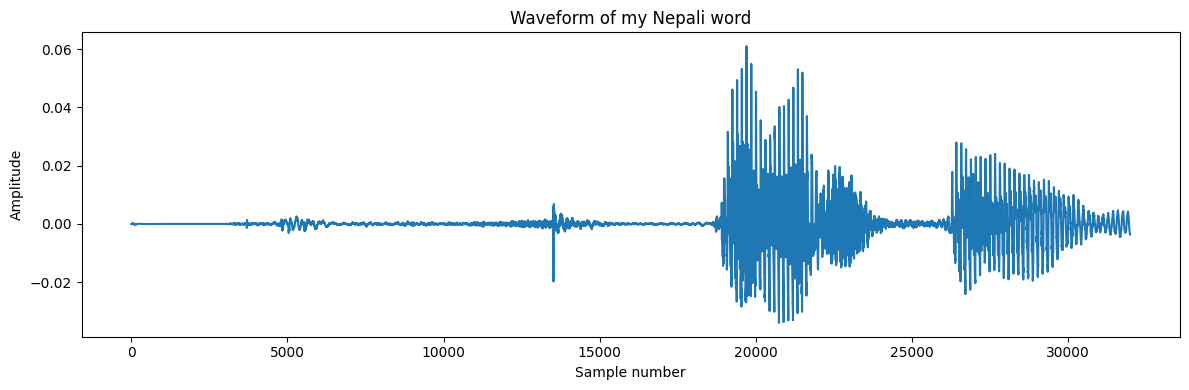

In [6]:
plt.figure(figsize=(12,4))
plt.plot(audio)
plt.title("Waveform of my Nepali word")
plt.xlabel("Sample number")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


In [7]:
mfcss = librosa.feature.mfcc(y=audio, sr=SAMPLE_RATE, n_mfcc=40)

print(f"Audio shape: {audio.shape}")
print(f"MFCC shape: {mfcss.shape}")

Audio shape: (32000,)
MFCC shape: (40, 63)


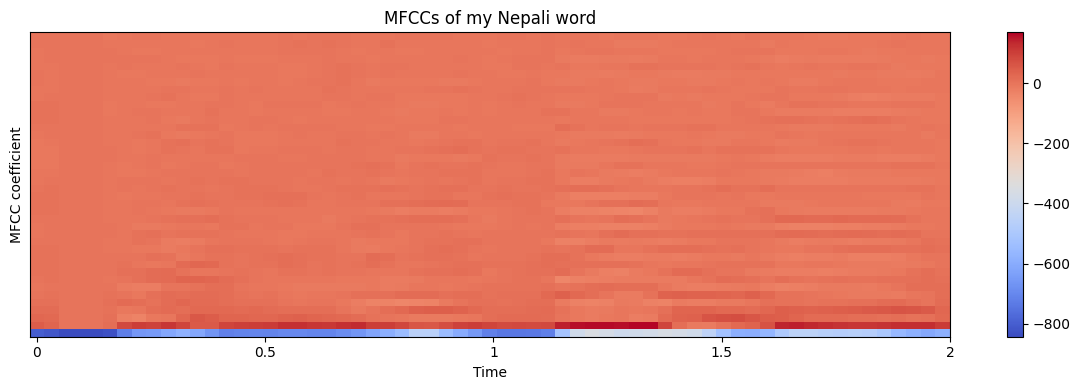

In [9]:
plt.figure(figsize=(12,4))
librosa.display.specshow(mfcss, sr=SAMPLE_RATE, x_axis='time')
plt.colorbar()
plt.title("MFCCs of my Nepali word")
plt.xlabel("Time")
plt.ylabel("MFCC coefficient")
plt.tight_layout()
plt.show()

In [10]:
sf.write('../data/raw/test_namaste.wav',audio,SAMPLE_RATE)
print("saved")

saved


In [11]:
keywords = {
    1: {"nepali": "बाल्नु", "romanized": "Baalnu", "meaning": "Turn On"},
    2: {"nepali": "बन्द", "romanized": "Banda", "meaning": "Turn Off"},
    3: {"nepali": "सुरु", "romanized": "Suru", "meaning": "Start"},
    4: {"nepali": "रोक्नु", "romanized": "Roknu", "meaning": "Stop/Pause"},
    5: {"nepali": "माथि", "romanized": "Maathi", "meaning": "Up"},
    6: {"nepali": "तल", "romanized": "Tala", "meaning": "Down"},
    7: {"nepali": "अर्को", "romanized": "Arko", "meaning": "Next"},
    8: {"nepali": "अघिल्लो", "romanized": "Aghillo", "meaning": "Previous"},
    9: {"nepali": "फेरि", "romanized": "Feri", "meaning": "Repeat"},
    10: {"nepali": "ठीक छ", "romanized": "Thik Chha", "meaning": "Confirm"},
    11: {"nepali": "हुन्छ", "romanized": "Huncha", "meaning": "Yes"},
    12: {"nepali": "होइन", "romanized": "Hoina", "meaning": "No"},
}

print(f"Total keywords : {len(keywords)}")
for k, v in keywords.items():
    print(f"{k}, {v['nepali']} ({v['romanized']} = {v['meaning']})")

Total keywords : 12
1, बाल्नु (Baalnu = Turn On)
2, बन्द (Banda = Turn Off)
3, सुरु (Suru = Start)
4, रोक्नु (Roknu = Stop/Pause)
5, माथि (Maathi = Up)
6, तल (Tala = Down)
7, अर्को (Arko = Next)
8, अघिल्लो (Aghillo = Previous)
9, फेरि (Feri = Repeat)
10, ठीक छ (Thik Chha = Confirm)
11, हुन्छ (Huncha = Yes)
12, होइन (Hoina = No)
